# 03i — E3d Official SBI with EfficientNet-B4 Training

**Experiment:** E3d — EfficientNet-B4 trained using the verified E3b official-SBI generation pipeline  
**Purpose:** Test whether compound detector scaling from EfficientNet-B0/224 to EfficientNet-B4/380 improves SBI performance and generalisation.

This notebook changes the E3b detector configuration as one declared compound intervention: **B0/224 → B4/380**. The FF++ video split, SBI metadata, official fake-generation logic, optimiser, learning rate, training budget and checkpoint-selection rule remain controlled.

It trains and validates on dynamic real/SBI pairs only. Genuine FF++ evaluation belongs in `04j_E3d_B4_FFPP_Evaluation.ipynb`; Celeb-DF evaluation must be performed later without retraining or threshold tuning.

## Experimental design

- **Research question:** Does scaling the strongest E3b pipeline from EfficientNet-B0/224 to the standard EfficientNet-B4/380 configuration improve internal and cross-dataset performance?
- **Hypothesis:** B4's greater capacity and 380×380 input may preserve and learn subtler SBI/manipulation artefacts than B0/224.
- **Control:** E3b — Official SBI + EfficientNet-B0 at 224×224
- **Compound independent variable:** detector scaling from B0/224 to B4/380
- **Training source:** the same clean video-level FF++ real train/validation frames, RetinaFace boxes and 81-point landmarks used by E3b
- **Dynamic labels:** real = 0; official SBI fake = 1
- **SBI logic:** unchanged official E3b generation; no FPNet and no FreqBlender
- **Preprocessing:** resize final real/SBI faces to 380×380, convert to float32 and divide by 255; no ImageNet mean/std normalisation
- **Model:** ImageNet-pretrained EfficientNet-B4, fully fine-tuned
- **Optimiser:** Adam, learning rate 0.0001, weight decay 0.0001
- **Memory-safe batching:** 4 source frames create 8 model images per micro-batch; two-step gradient accumulation preserves an effective optimiser batch of 16 images
- **Epochs:** 10
- **Model selection:** highest synthetic validation ROC-AUC
- **Checkpoint:** `saved_models/efficientnet_b4_official_sbi_best.pth`

The synthetic validation result selects a checkpoint; it is not evidence of generalisation. E3d must subsequently be tested on genuine FF++ and the fixed Celeb-DF pilot using threshold 0.5.

## 1. Safety controls

Training and checkpoint replacement are disabled by default. Set `RUN_TRAINING = True` to train E3d. Keep `ALLOW_CHECKPOINT_OVERWRITE = False` unless you deliberately intend to replace an existing E3d checkpoint.

In [1]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

CHECKPOINT_NAME = "efficientnet_b4_official_sbi_best.pth"
RESULTS_NAME = "efficientnet_b4_official_sbi_training_results.json"
LOSS_PLOT_NAME = "efficientnet_b4_official_sbi_loss.png"
ACCURACY_PLOT_NAME = "efficientnet_b4_official_sbi_accuracy.png"
AUC_PLOT_NAME = "efficientnet_b4_official_sbi_auc.png"

print("E3d training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("E3d checkpoint:", CHECKPOINT_NAME)

E3d training enabled: True
Allow checkpoint overwrite: False
E3d checkpoint: efficientnet_b4_official_sbi_best.pth


## 2. Mount Drive and validate project paths

This cell mounts Google Drive, resolves the existing prepared SBI data and protects any previous E3d checkpoint. It does not rebuild or modify the dataset.

In [2]:
from google.colab import drive
from pathlib import Path
import torch

drive.mount("/content/drive")

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
SBI_BASE = BASE_PATH / "sbi_dataset"
SPLIT_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"
MODEL_DIR = BASE_PATH / "saved_models"
RESULTS_DIR = BASE_PATH / "results"
PLOTS_DIR = BASE_PATH / "plots"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / CHECKPOINT_NAME
RESULTS_PATH = RESULTS_DIR / RESULTS_NAME

assert SBI_BASE.is_dir(), f"Prepared SBI dataset not found: {SBI_BASE}"
assert SPLIT_MANIFEST_PATH.is_file(), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"

if RUN_TRAINING and MODEL_PATH.exists() and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"Checkpoint already exists: {MODEL_PATH}. Set ALLOW_CHECKPOINT_OVERWRITE = True only if replacement is intentional."
    )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("SBI data:", SBI_BASE)
print("Checkpoint:", MODEL_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
SBI data: /content/drive/MyDrive/deepfake_project/sbi_dataset
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b4_official_sbi_best.pth
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Restore the official SBI utility repository

Colab's `/content` storage is temporary, so the official SBI repository is restored when missing. This does not alter the prepared dataset or saved checkpoints.

In [3]:
import os
import subprocess

OFFICIAL_REPOSITORY = "/content/SelfBlendedImages"

if not os.path.isdir(OFFICIAL_REPOSITORY):
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/mapooon/SelfBlendedImages.git",
            OFFICIAL_REPOSITORY,
        ],
        check=True,
    )
    print("Official SBI repository restored.")
else:
    print("Official SBI repository already available.")

Official SBI repository restored.


## 4. Audit SBI metadata against the clean video split

E3d must use exactly the same complete FF++ real-frame, RetinaFace and landmark triplets used by E3b. This audit checks membership, counts and zero train/validation video overlap.

In [4]:
import json
import pandas as pd

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

with SPLIT_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

expected_counts = {"train": 1342, "val": 290}
audit_rows = []
observed_videos = {}

for split in ("train", "val"):
    frames_root = SBI_BASE / split / "frames" / "real"
    retina_root = SBI_BASE / split / "retina" / "real"
    landmarks_root = SBI_BASE / split / "landmarks" / "real"
    for required in (frames_root, retina_root, landmarks_root):
        assert required.is_dir(), f"Required SBI folder not found: {required}"

    complete_triplets = 0
    video_names = set()
    for video_folder in sorted(path for path in frames_root.iterdir() if path.is_dir()):
        video_names.add(video_folder.name)
        for frame_path in video_folder.iterdir():
            if frame_path.is_file() and frame_path.suffix.lower() in IMAGE_EXTENSIONS:
                retina_path = retina_root / video_folder.name / f"{frame_path.stem}.npy"
                landmark_path = landmarks_root / video_folder.name / f"{frame_path.stem}.npy"
                complete_triplets += int(retina_path.is_file() and landmark_path.is_file())

    expected_videos = {Path(name).stem for name in split_manifest["classes"]["real"][split]}
    assert video_names == expected_videos, (
        f"{split} SBI video folders do not exactly match the saved manifest. "
        f"Missing: {sorted(expected_videos - video_names)[:5]}; "
        f"unexpected: {sorted(video_names - expected_videos)[:5]}"
    )
    assert complete_triplets == expected_counts[split], (
        f"Expected {expected_counts[split]} complete {split} triplets, found {complete_triplets}."
    )
    observed_videos[split] = video_names
    audit_rows.append({
        "split": split,
        "complete_triplets": complete_triplets,
        "source_videos": len(video_names),
        "expected_triplets": expected_counts[split],
    })

overlap = observed_videos["train"] & observed_videos["val"]
assert not overlap, f"Train/validation video leakage detected: {sorted(overlap)[:5]}"

display(pd.DataFrame(audit_rows))
print("PASS: E3d uses complete SBI metadata from the clean video-level split.")


,split,complete_triplets,source_videos,expected_triplets
0,train,1342,140,1342
1,val,290,30,290


PASS: E3d uses complete SBI metadata from the clean video-level split.


## 5. Official SBI generation at 380×380

This cell preserves the verified E3b official SBI logic and changes only the final detector-facing image size to 380×380. Synthetic images are generated dynamically in memory and are not written to Drive. No FreqBlender or FPNet operation is included.

Official SBI helper functions imported successfully.
Official SBI train source frames: 1342
Official SBI val source frames: 290

Official SBI batch shape: torch.Size([8, 3, 380, 380])
Official SBI label shape: torch.Size([8])
Labels: [0, 0, 0, 0, 1, 1, 1, 1]


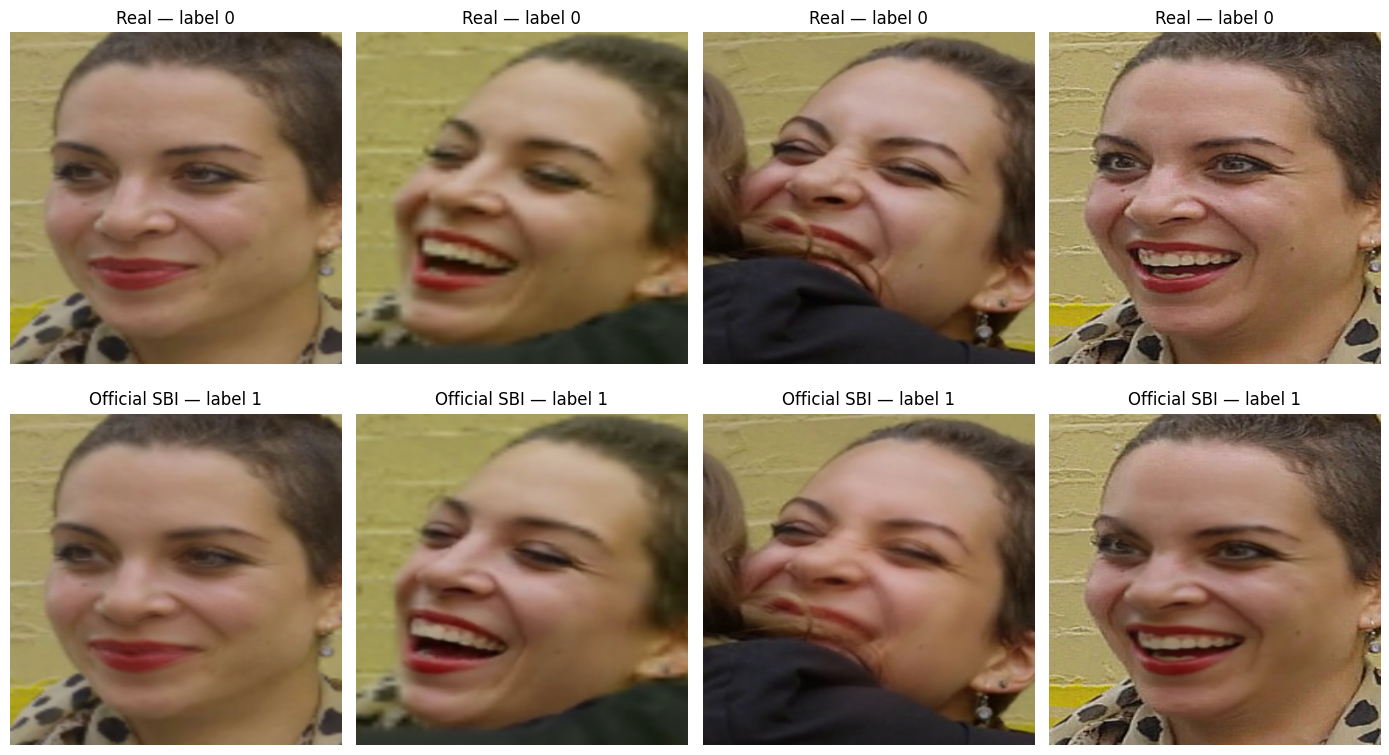

In [5]:
# ============================================================
# E3d: Official SBI Fake Generation on Our Dataset
#
# Uses OUR existing preprocessed dataset:
#   sbi_dataset/<split>/frames/real/
#   sbi_dataset/<split>/retina/real/
#   sbi_dataset/<split>/landmarks/real/
#
# Uses OFFICIAL SBI generation logic:
#   - official crop_face()
#   - official IoU face matching
#   - official landmark reordering and horizontal flip
#   - official source transforms
#   - official affine + elastic mask transformation
#   - official dynamic blending
#   - official paired post-blending augmentation
#
# No files are deleted or generated permanently.
# Synthetic images are created dynamically in memory.
# ============================================================

import os
import sys
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as alb

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths and reproducibility
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

official_repo = "/content/SelfBlendedImages"
official_src = os.path.join(official_repo, "src")

if not os.path.exists(official_repo):
    raise RuntimeError(
        "Official SBI repository is missing from /content. "
        "Clone or restore SelfBlendedImages after restarting Colab."
    )

if official_src not in sys.path:
    sys.path.insert(0, official_src)

RANDOM_SEED = 42
IMAGE_SIZE = 380

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# Import official SBI helper implementations
# ------------------------------------------------------------

from utils import blend as official_blend
from utils.funcs import (
    IoUfrom2bboxes,
    crop_face,
    RandomDownScale
)

print("Official SBI helper functions imported successfully.")


# ------------------------------------------------------------
# Albumentations compatibility helpers
#
# The official repository was written for an older version of
# Albumentations. These wrappers preserve the same parameters
# while supporting current Colab versions.
# ------------------------------------------------------------

def make_image_compression():
    import inspect

    parameters = inspect.signature(
        alb.ImageCompression.__init__
    ).parameters

    if "quality_range" in parameters:
        return alb.ImageCompression(
            quality_range=(40, 100),
            p=0.5
        )

    return alb.ImageCompression(
        quality_lower=40,
        quality_upper=100,
        p=0.5
    )


def make_elastic_transform():
    import inspect

    parameters = inspect.signature(
        alb.ElasticTransform.__init__
    ).parameters

    arguments = {
        "alpha": 50,
        "sigma": 7,
        "p": 1,
    }

    # The official legacy configuration used alpha_affine=0.
    # New releases removed this no-op argument.
    if "alpha_affine" in parameters:
        arguments["alpha_affine"] = 0

    return alb.ElasticTransform(**arguments)


# ------------------------------------------------------------
# Official-style SBI Dataset adapted only to our file paths
# ------------------------------------------------------------

class OfficialSBIDatasetFromOurData(Dataset):

    def __init__(
        self,
        root_path,
        phase="train",
        image_size=380
    ):
        assert phase in ["train", "val"]

        self.root_path = root_path
        self.phase = phase
        self.image_size = (
            image_size,
            image_size
        )

        self.frames_root = os.path.join(
            root_path,
            phase,
            "frames",
            "real"
        )

        self.retina_root = os.path.join(
            root_path,
            phase,
            "retina",
            "real"
        )

        self.landmarks_root = os.path.join(
            root_path,
            phase,
            "landmarks",
            "real"
        )

        self.samples = []

        for video_name in sorted(
            os.listdir(self.frames_root)
        ):
            frame_folder = os.path.join(
                self.frames_root,
                video_name
            )

            if not os.path.isdir(frame_folder):
                continue

            for frame_file in sorted(
                os.listdir(frame_folder)
            ):
                if not frame_file.lower().endswith(
                    ".png"
                ):
                    continue

                stem = os.path.splitext(
                    frame_file
                )[0]

                frame_path = os.path.join(
                    frame_folder,
                    frame_file
                )

                retina_path = os.path.join(
                    self.retina_root,
                    video_name,
                    stem + ".npy"
                )

                landmark_path = os.path.join(
                    self.landmarks_root,
                    video_name,
                    stem + ".npy"
                )

                if (
                    os.path.exists(frame_path)
                    and os.path.exists(retina_path)
                    and os.path.exists(landmark_path)
                ):
                    self.samples.append({
                        "frame": frame_path,
                        "retina": retina_path,
                        "landmarks": landmark_path
                    })

        self.transforms = self.get_transforms()
        self.source_transforms = (
            self.get_source_transforms()
        )

        print(
            f"Official SBI {phase} source frames:",
            len(self.samples)
        )

    def __len__(self):
        return len(self.samples)

    # --------------------------------------------------------
    # Official SBI source transformation
    # --------------------------------------------------------

    def get_source_transforms(self):
        return alb.Compose([
            alb.Compose([
                alb.RGBShift(
                    r_shift_limit=(-20, 20),
                    g_shift_limit=(-20, 20),
                    b_shift_limit=(-20, 20),
                    p=0.3
                ),

                alb.HueSaturationValue(
                    hue_shift_limit=(-0.3, 0.3),
                    sat_shift_limit=(-0.3, 0.3),
                    val_shift_limit=(-0.3, 0.3),
                    p=1
                ),

                alb.RandomBrightnessContrast(
                    brightness_limit=(-0.1, 0.1),
                    contrast_limit=(-0.1, 0.1),
                    p=1
                ),
            ], p=1),

            alb.OneOf([
                RandomDownScale(p=1),

                alb.Sharpen(
                    alpha=(0.2, 0.5),
                    lightness=(0.5, 1.0),
                    p=1
                ),
            ], p=1),
        ], p=1)

    # --------------------------------------------------------
    # Official paired transformation
    #
    # The same random post-blending changes are applied to both
    # the real and generated fake image.
    # --------------------------------------------------------

    def get_transforms(self):
        return alb.Compose([
            alb.RGBShift(
                r_shift_limit=(-20, 20),
                g_shift_limit=(-20, 20),
                b_shift_limit=(-20, 20),
                p=0.3
            ),

            alb.HueSaturationValue(
                hue_shift_limit=(-0.3, 0.3),
                sat_shift_limit=(-0.3, 0.3),
                val_shift_limit=(-0.3, 0.3),
                p=0.3
            ),

            alb.RandomBrightnessContrast(
                brightness_limit=(-0.3, 0.3),
                contrast_limit=(-0.3, 0.3),
                p=0.3
            ),

            make_image_compression(),
        ],
        additional_targets={
            "image1": "image"
        },
        p=1)

    # --------------------------------------------------------
    # Official affine and elastic transformation
    # --------------------------------------------------------

    def randaffine(
        self,
        image,
        mask
    ):
        affine_transform = alb.Affine(
            translate_percent={
                "x": (-0.03, 0.03),
                "y": (-0.015, 0.015)
            },
            scale=(0.95, 1 / 0.95),
            fit_output=False,
            p=1
        )

        elastic_transform = (
            make_elastic_transform()
        )

        transformed = affine_transform(
            image=image,
            mask=mask
        )

        image = transformed["image"]
        mask = transformed["mask"]

        transformed = elastic_transform(
            image=image,
            mask=mask
        )

        mask = transformed["mask"]

        return image, mask

    # --------------------------------------------------------
    # Official landmark ordering
    # --------------------------------------------------------

    def reorder_landmark(
        self,
        landmark
    ):
        landmark = landmark.copy()

        landmark_add = np.zeros(
            (13, 2),
            dtype=landmark.dtype
        )

        official_order = [
            77, 75, 76, 68, 69, 70, 71,
            80, 72, 73, 79, 74, 78
        ]

        for new_index, old_index in enumerate(
            official_order
        ):
            landmark_add[new_index] = (
                landmark[old_index]
            )

        landmark[68:] = landmark_add

        return landmark

    # --------------------------------------------------------
    # Official horizontal flip
    #
    # This mirrors coordinates and reorders anatomical indices.
    # --------------------------------------------------------

    def hflip(
        self,
        image,
        mask=None,
        landmark=None,
        bbox=None
    ):
        height, width = image.shape[:2]

        landmark_new = None
        bbox_new = None

        if landmark is not None:
            landmark = landmark.copy()
            landmark_new = np.zeros_like(
                landmark
            )

            landmark_new[:17] = (
                landmark[:17][::-1]
            )

            landmark_new[17:27] = (
                landmark[17:27][::-1]
            )

            landmark_new[27:31] = (
                landmark[27:31]
            )

            landmark_new[31:36] = (
                landmark[31:36][::-1]
            )

            landmark_new[36:40] = (
                landmark[42:46][::-1]
            )

            landmark_new[40:42] = (
                landmark[46:48][::-1]
            )

            landmark_new[42:46] = (
                landmark[36:40][::-1]
            )

            landmark_new[46:48] = (
                landmark[40:42][::-1]
            )

            landmark_new[48:55] = (
                landmark[48:55][::-1]
            )

            landmark_new[55:60] = (
                landmark[55:60][::-1]
            )

            landmark_new[60:65] = (
                landmark[60:65][::-1]
            )

            landmark_new[65:68] = (
                landmark[65:68][::-1]
            )

            if len(landmark) == 81:
                landmark_new[68:81] = (
                    landmark[68:81][::-1]
                )

            elif len(landmark) != 68:
                raise NotImplementedError(
                    "Expected 68 or 81 landmarks."
                )

            landmark_new[:, 0] = (
                width - landmark_new[:, 0]
            )

        if bbox is not None:
            bbox = bbox.copy()
            bbox_new = np.zeros_like(bbox)

            bbox_new[0, 0] = bbox[1, 0]
            bbox_new[1, 0] = bbox[0, 0]

            bbox_new[:, 0] = (
                width - bbox_new[:, 0]
            )

            bbox_new[:, 1] = (
                bbox[:, 1].copy()
            )

            if len(bbox) > 2:
                bbox_new[2, 0] = (
                    width - bbox[3, 0]
                )
                bbox_new[2, 1] = bbox[3, 1]

                bbox_new[3, 0] = (
                    width - bbox[2, 0]
                )
                bbox_new[3, 1] = bbox[2, 1]

                bbox_new[4, 0] = (
                    width - bbox[4, 0]
                )
                bbox_new[4, 1] = bbox[4, 1]

                bbox_new[5, 0] = (
                    width - bbox[6, 0]
                )
                bbox_new[5, 1] = bbox[6, 1]

                bbox_new[6, 0] = (
                    width - bbox[5, 0]
                )
                bbox_new[6, 1] = bbox[5, 1]

        if mask is not None:
            mask = mask[:, ::-1]

        image = image[:, ::-1].copy()

        return (
            image,
            mask,
            landmark_new,
            bbox_new
        )

    # --------------------------------------------------------
    # Official self-blending logic
    #
    # Because the optional BI mask library is not included in
    # the public repository, this uses the official fallback:
    # cv2.convexHull over the dense landmarks.
    # --------------------------------------------------------

    def self_blending(
        self,
        image,
        landmark
    ):
        mask = np.zeros_like(
            image[:, :, 0],
            dtype=np.float32
        )

        if np.random.rand() < 0.25:
            landmark_for_mask = landmark[:68]
        else:
            landmark_for_mask = landmark

        cv2.fillConvexPoly(
            mask,
            cv2.convexHull(
                landmark_for_mask.astype(
                    np.int32
                )
            ),
            1.0
        )

        source = image.copy()
        target = image.copy()

        # Official code randomly transforms source or target.
        if np.random.rand() < 0.5:
            source = self.source_transforms(
                image=source.astype(np.uint8)
            )["image"]

        else:
            target = self.source_transforms(
                image=target.astype(np.uint8)
            )["image"]

        source, mask = self.randaffine(
            source,
            mask
        )

        blended, mask = (
            official_blend.dynamic_blend(
                source,
                target,
                mask
            )
        )

        blended = blended.astype(np.uint8)
        target = target.astype(np.uint8)

        return target, blended, mask

    # --------------------------------------------------------
    # Load and dynamically generate one official SBI pair
    # --------------------------------------------------------

    def _generate_pair(
        self,
        index
    ):
        sample = self.samples[index]

        image = np.array(
            Image.open(sample["frame"])
            .convert("RGB")
        )

        landmark_array = np.load(
            sample["landmarks"]
        )

        retina_array = np.load(
            sample["retina"]
        )

        landmark = (
            landmark_array[0]
            .astype(np.float32)
        )

        # Dense-landmark bounding rectangle
        bbox_landmark = np.array([
            landmark[:, 0].min(),
            landmark[:, 1].min(),
            landmark[:, 0].max(),
            landmark[:, 1].max()
        ])

        # Select RetinaFace box with highest IoU.
        maximum_iou = -1
        bbox = None

        for candidate in retina_array:
            candidate_iou = (
                IoUfrom2bboxes(
                    bbox_landmark,
                    candidate.flatten()[:4]
                )
            )

            if candidate_iou > maximum_iou:
                bbox = candidate.copy()
                maximum_iou = candidate_iou

        if bbox is None:
            raise RuntimeError(
                "No RetinaFace box matched landmarks."
            )

        landmark = self.reorder_landmark(
            landmark
        )

        # Official random training flip.
        if (
            self.phase == "train"
            and np.random.rand() < 0.5
        ):
            (
                image,
                _,
                landmark,
                bbox
            ) = self.hflip(
                image,
                None,
                landmark,
                bbox
            )

        # Official enlarged working crop.
        (
            image,
            landmark,
            bbox,
            _
        ) = crop_face(
            image,
            landmark,
            bbox,
            margin=True,
            crop_by_bbox=False,
            phase=self.phase
        )

        # Generate official SBI pair.
        image_real, image_fake, _ = (
            self.self_blending(
                image.copy(),
                landmark.copy()
            )
        )

        # Official paired post-blending augmentation.
        if self.phase == "train":
            transformed = self.transforms(
                image=image_fake.astype(
                    np.uint8
                ),
                image1=image_real.astype(
                    np.uint8
                )
            )

            image_fake = transformed["image"]
            image_real = transformed["image1"]

        # Official final crop from generated fake.
        (
            image_fake,
            _,
            _,
            _,
            y0,
            y1,
            x0,
            x1
        ) = crop_face(
            image_fake,
            landmark,
            bbox,
            margin=False,
            crop_by_bbox=True,
            abs_coord=True,
            phase=self.phase
        )

        # Apply identical coordinates to real image.
        image_real = image_real[
            y0:y1,
            x0:x1
        ]

        if (
            image_fake.size == 0
            or image_real.size == 0
        ):
            raise ValueError(
                "Official SBI created empty crop."
            )

        # Official SBI output is resized and divided by 255.
        image_fake = cv2.resize(
            image_fake,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_real = cv2.resize(
            image_real,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_fake = image_fake.transpose(
            2,
            0,
            1
        )

        image_real = image_real.transpose(
            2,
            0,
            1
        )

        return (
            torch.tensor(
                image_fake,
                dtype=torch.float32
            ),
            torch.tensor(
                image_real,
                dtype=torch.float32
            )
        )

    def __getitem__(
        self,
        index
    ):
        # Keep validation output deterministic.
        if self.phase == "val":
            python_state = random.getstate()
            numpy_state = np.random.get_state()

            random.seed(
                RANDOM_SEED + index
            )
            np.random.seed(
                RANDOM_SEED + index
            )

        try:
            fake_tensor, real_tensor = (
                self._generate_pair(index)
            )

        except Exception as error:
            replacement_index = random.randrange(
                len(self.samples)
            )

            print(
                f"Official SBI sample error at "
                f"index {index}: {error}. "
                f"Using replacement index "
                f"{replacement_index}."
            )

            fake_tensor, real_tensor = (
                self._generate_pair(
                    replacement_index
                )
            )

        if self.phase == "val":
            random.setstate(
                python_state
            )
            np.random.set_state(
                numpy_state
            )

        return fake_tensor, real_tensor


# ------------------------------------------------------------
# Official collate logic
# ------------------------------------------------------------

def official_sbi_collate_fn(batch):
    fake_images, real_images = zip(*batch)

    real_batch = torch.stack(
        real_images
    )

    fake_batch = torch.stack(
        fake_images
    )

    images = torch.cat(
        [
            real_batch,
            fake_batch
        ],
        dim=0
    )

    labels = torch.tensor(
        [0] * len(real_images)
        + [1] * len(fake_images),
        dtype=torch.long
    )

    return {
        "images": images,
        "labels": labels
    }


# ------------------------------------------------------------
# Create E3d loaders
# ------------------------------------------------------------

official_sbi_train_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="train",
        image_size=IMAGE_SIZE
    )
)

official_sbi_val_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="val",
        image_size=IMAGE_SIZE
    )
)

# Eight source frames produce:
# 8 real + 8 official SBI fake = 16 model inputs.
OFFICIAL_SBI_SOURCE_BATCH_SIZE = 4

official_sbi_train_loader = DataLoader(
    official_sbi_train_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=True,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

official_sbi_val_loader = DataLoader(
    official_sbi_val_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=False,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Sanity-check one official SBI batch
# ------------------------------------------------------------

official_batch = next(
    iter(official_sbi_train_loader)
)

print()
print(
    "Official SBI batch shape:",
    official_batch["images"].shape
)

print(
    "Official SBI label shape:",
    official_batch["labels"].shape
)

print(
    "Labels:",
    official_batch["labels"].tolist()
)


# ------------------------------------------------------------
# Display four deterministic validation real/official-SBI pairs
# ------------------------------------------------------------

official_preview_batch = next(
    iter(official_sbi_val_loader)
)

number_of_pairs = 4

plt.figure(figsize=(14, 8))

for pair_index in range(
    number_of_pairs
):
    real_image = (
        official_preview_batch["images"][
            pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    fake_image = (
        official_preview_batch["images"][
            OFFICIAL_SBI_SOURCE_BATCH_SIZE
            + pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    plt.subplot(
        2,
        number_of_pairs,
        pair_index + 1
    )

    plt.imshow(
        np.clip(real_image, 0, 1)
    )

    plt.title(
        "Real — label 0"
    )

    plt.axis("off")

    plt.subplot(
        2,
        number_of_pairs,
        number_of_pairs
        + pair_index
        + 1
    )

    plt.imshow(
        np.clip(fake_image, 0, 1)
    )

    plt.title(
        "Official SBI — label 1"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Train and save E3d

EfficientNet-B4 is fully fine-tuned for the same 10 epochs, with the same Adam settings and best-validation-ROC-AUC rule as E3b. Gradient accumulation keeps the effective optimiser batch at 16 images while reducing peak GPU memory.

Using device: cuda
GPU: Tesla T4
Real training source frames: 1342
Real validation source frames: 290
Source batch size: 4
Model micro-batch size: 8
Gradient accumulation steps: 2
Effective optimiser batch size: 16
Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 140MB/s]


Trainable parameters: 17,552,202
Epoch 1 Batch 0/335 Loss: 0.7094
Epoch 1 Batch 20/335 Loss: 0.6964
Epoch 1 Batch 40/335 Loss: 0.6889
Epoch 1 Batch 60/335 Loss: 0.6713
Epoch 1 Batch 80/335 Loss: 0.6929
Epoch 1 Batch 100/335 Loss: 0.6846
Epoch 1 Batch 120/335 Loss: 0.6951
Epoch 1 Batch 140/335 Loss: 0.6825
Epoch 1 Batch 160/335 Loss: 0.6711
Epoch 1 Batch 180/335 Loss: 0.6957
Epoch 1 Batch 200/335 Loss: 0.7289
Epoch 1 Batch 220/335 Loss: 0.6694
Epoch 1 Batch 240/335 Loss: 0.6559
Epoch 1 Batch 260/335 Loss: 0.5743
Epoch 1 Batch 280/335 Loss: 0.6819
Epoch 1 Batch 300/335 Loss: 0.6283
Epoch 1 Batch 320/335 Loss: 0.5334

Epoch [1/10]
Train Loss: 0.6641 | Train Acc: 61.34% | Train Precision: 61.63% | Train Recall: 61.34% | Train F1: 61.10% | Train AUC: 0.6738
Val Loss: 0.5470 | Val Acc: 80.17% | Val Precision: 80.18% | Val Recall: 80.17% | Val F1: 80.17% | Val AUC: 0.8836
Learning rate: 0.00010000
Epoch time: 34.56 minutes
*** Best official SBI model updated at Epoch 1 | Val AUC: 0.8836 | Val

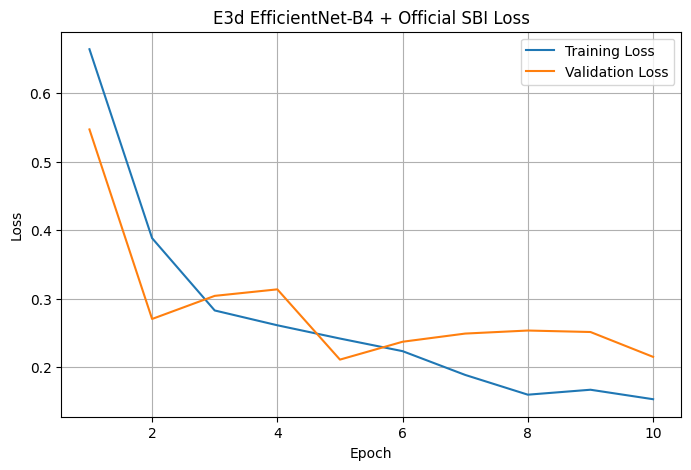

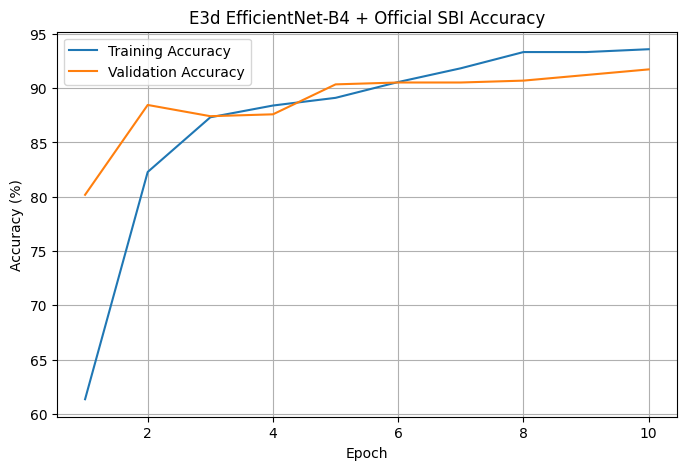

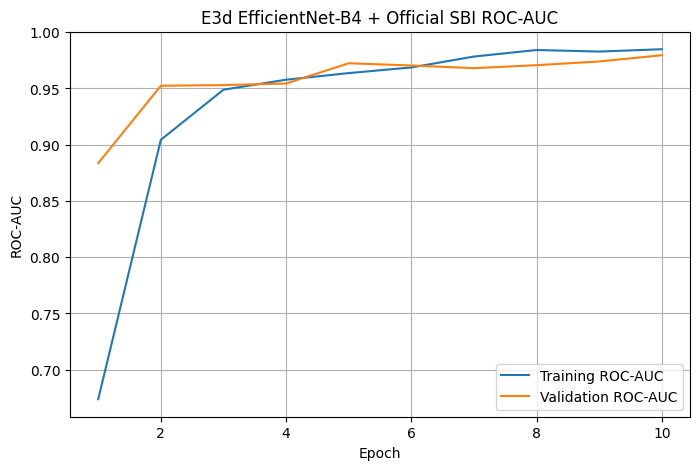

In [6]:
# ============================================================
# E3d: EfficientNet-B4 with Official SBI Fake Generation
#
# Training source:
#   Real FF++ training frames only
#
# Dynamic training pairs:
#   Original real image -> label 0
#   Official SBI fake   -> label 1
#
# Validation:
#   Real validation frames + dynamically generated SBI fakes
#
# Backbone:
#   ImageNet-pretrained EfficientNet-B4
#   Full fine-tuning
#
# Model selection:
#   Best validation ROC-AUC
#
# Safety:
#   Does not overwrite the previous E3a model or results.
# ============================================================

if RUN_TRAINING:
    import os
    import json
    import time
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    from torchvision.models import (
        efficientnet_b4,
        EfficientNet_B4_Weights
    )

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score
    )

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    base_path = "/content/drive/MyDrive/deepfake_project"

    model_dir = os.path.join(
        base_path,
        "saved_models"
    )

    results_dir = os.path.join(
        base_path,
        "results"
    )

    plots_dir = os.path.join(
        base_path,
        "plots"
    )

    os.makedirs(
        model_dir,
        exist_ok=True
    )

    os.makedirs(
        results_dir,
        exist_ok=True
    )

    os.makedirs(
        plots_dir,
        exist_ok=True
    )

    model_path = os.path.join(
        model_dir,
        CHECKPOINT_NAME
    )

    results_path = os.path.join(
        results_dir,
        RESULTS_NAME
    )

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("Using device:", device)

    if torch.cuda.is_available():
        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Confirm required loaders exist
    # --------------------------------------------------------

    required_objects = [
        "official_sbi_train_loader",
        "official_sbi_val_loader",
        "OFFICIAL_SBI_SOURCE_BATCH_SIZE"
    ]

    missing_objects = [
        name
        for name in required_objects
        if name not in globals()
    ]

    if missing_objects:
        raise RuntimeError(
            "Run the official SBI loader cell first. "
            f"Missing objects: {missing_objects}"
        )

    print(
        "Real training source frames:",
        len(official_sbi_train_loader.dataset)
    )

    print(
        "Real validation source frames:",
        len(official_sbi_val_loader.dataset)
    )

    print(
        "Source batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE
    )

    print(
        "Model micro-batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2
    )

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    RANDOM_SEED = 42

    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    torch.manual_seed(RANDOM_SEED)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            RANDOM_SEED
        )

    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    NUM_EPOCHS = 10
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-4
    GRADIENT_ACCUMULATION_STEPS = 2

    print(
        "Gradient accumulation steps:",
        GRADIENT_ACCUMULATION_STEPS
    )
    print(
        "Effective optimiser batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE
        * 2
        * GRADIENT_ACCUMULATION_STEPS
    )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    weights = EfficientNet_B4_Weights.DEFAULT

    model = efficientnet_b4(
        weights=weights
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    # Full fine-tuning:
    # no EfficientNet layers are frozen.
    for parameter in model.parameters():
        parameter.requires_grad = True

    model = model.to(device)

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # Loss, optimiser and scheduler
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    # --------------------------------------------------------
    # Metric helper
    # --------------------------------------------------------

    def calculate_binary_metrics(
        labels,
        predictions,
        fake_probabilities
    ):
        accuracy = accuracy_score(
            labels,
            predictions
        ) * 100

        precision = precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        recall = recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        try:
            auc = roc_auc_score(
                labels,
                fake_probabilities
            )
        except ValueError:
            auc = None

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc
        }

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],

        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],

        "learning_rate": []
    }

    best_val_auc = -1.0
    best_val_accuracy = 0.0
    best_val_f1 = 0.0
    best_epoch = 0

    training_start_time = time.time()

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(NUM_EPOCHS):

        epoch_start_time = time.time()

        # ====================================================
        # Training phase
        # ====================================================

        model.train()

        running_train_loss = 0.0

        train_labels = []
        train_predictions = []
        train_probabilities = []

        optimizer.zero_grad(
            set_to_none=True
        )

        for batch_index, batch in enumerate(
            official_sbi_train_loader
        ):
            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            scaled_loss = (
                loss
                / GRADIENT_ACCUMULATION_STEPS
            )
            scaled_loss.backward()

            accumulation_boundary = (
                (batch_index + 1)
                % GRADIENT_ACCUMULATION_STEPS
                == 0
                or batch_index + 1
                == len(official_sbi_train_loader)
            )

            if accumulation_boundary:
                optimizer.step()
                optimizer.zero_grad(
                    set_to_none=True
                )

            running_train_loss += (
                loss.item()
            )

            fake_probabilities = (
                torch.softmax(
                    outputs,
                    dim=1
                )[:, 1]
            )

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            train_labels.extend(
                labels
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_predictions.extend(
                predictions
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_probabilities.extend(
                fake_probabilities
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            if batch_index % 20 == 0:
                print(
                    f"Epoch {epoch + 1} "
                    f"Batch {batch_index}/"
                    f"{len(official_sbi_train_loader)} "
                    f"Loss: {loss.item():.4f}"
                )

        average_train_loss = (
            running_train_loss
            / len(official_sbi_train_loader)
        )

        train_metrics = (
            calculate_binary_metrics(
                train_labels,
                train_predictions,
                train_probabilities
            )
        )

        # ====================================================
        # Validation phase
        # ====================================================

        model.eval()

        running_val_loss = 0.0

        val_labels = []
        val_predictions = []
        val_probabilities = []

        with torch.no_grad():

            for batch in official_sbi_val_loader:
                images = batch["images"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["labels"].to(
                    device,
                    non_blocking=True
                )

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item()
                )

                fake_probabilities = (
                    torch.softmax(
                        outputs,
                        dim=1
                    )[:, 1]
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_labels.extend(
                    labels
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_predictions.extend(
                    predictions
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_probabilities.extend(
                    fake_probabilities
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

        average_val_loss = (
            running_val_loss
            / len(official_sbi_val_loader)
        )

        val_metrics = (
            calculate_binary_metrics(
                val_labels,
                val_predictions,
                val_probabilities
            )
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        scheduler_value = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else val_metrics["accuracy"] / 100
        )

        scheduler.step(
            scheduler_value
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            average_train_loss
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        history["val_loss"].append(
            average_val_loss
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        history["learning_rate"].append(
            current_learning_rate
        )

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        # ----------------------------------------------------
        # Epoch logging
        # ----------------------------------------------------

        print()
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
        )

        print(
            f"Train Loss: "
            f"{average_train_loss:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.2f}% | "
            f"Train Precision: "
            f"{train_metrics['precision']:.2f}% | "
            f"Train Recall: "
            f"{train_metrics['recall']:.2f}% | "
            f"Train F1: "
            f"{train_metrics['f1']:.2f}% | "
            f"Train AUC: "
            f"{train_metrics['roc_auc']:.4f}"
        )

        print(
            f"Val Loss: "
            f"{average_val_loss:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.2f}% | "
            f"Val Precision: "
            f"{val_metrics['precision']:.2f}% | "
            f"Val Recall: "
            f"{val_metrics['recall']:.2f}% | "
            f"Val F1: "
            f"{val_metrics['f1']:.2f}% | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
        )

        print(
            "Learning rate:",
            f"{current_learning_rate:.8f}"
        )

        print(
            "Epoch time:",
            f"{epoch_time / 60:.2f} minutes"
        )

        # ----------------------------------------------------
        # Save checkpoint with best validation ROC-AUC
        # ----------------------------------------------------

        current_val_auc = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"]
            is not None
            else -1.0
        )

        if current_val_auc > best_val_auc:

            best_val_auc = (
                current_val_auc
            )

            best_val_accuracy = (
                val_metrics["accuracy"]
            )

            best_val_f1 = (
                val_metrics["f1"]
            )

            best_epoch = epoch + 1

            checkpoint = {
                "experiment": "E3d",

                "model_name":
                    "EfficientNet-B4 + Official SBI",

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "epoch":
                    best_epoch,

                "best_val_auc":
                    best_val_auc,

                "best_val_accuracy":
                    best_val_accuracy,

                "best_val_f1":
                    best_val_f1,

                "learning_rate":
                    LEARNING_RATE,

                "weight_decay":
                    WEIGHT_DECAY,

                "source_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE,

                "micro_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

                "gradient_accumulation_steps":
                    GRADIENT_ACCUMULATION_STEPS,

                "effective_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2 * GRADIENT_ACCUMULATION_STEPS,

                "classes": [
                    "real",
                    "fake"
                ],

                "preprocessing":
                    "resize 380x380; float32 / 255; no ImageNet normalisation",

                "split_unit":
                    "source_video",

                "seed":
                    RANDOM_SEED
            }

            torch.save(
                checkpoint,
                model_path
            )

            print(
                "*** Best official SBI model "
                f"updated at Epoch {best_epoch} | "
                f"Val AUC: {best_val_auc:.4f} | "
                f"Val Accuracy: "
                f"{best_val_accuracy:.2f}% | "
                f"Val F1: {best_val_f1:.2f}% ***"
            )

        print("-" * 75)

    # --------------------------------------------------------
    # Training completed
    # --------------------------------------------------------

    total_training_time = (
        time.time()
        - training_start_time
    )

    training_results = {
        "experiment": "E3d",

        "model":
            "EfficientNet-B4 + Official SBI",

        "backbone":
            "EfficientNet-B4",

        "pretrained_on":
            "ImageNet",

        "fine_tuning":
            True,

        "backbone_frozen":
            False,

        "training_source":
            "Real FF++ training videos only",

        "genuine_fake_training_images_used":
            False,

        "synthetic_fake_generation":
            "Official SBI generation logic",

        "epochs":
            NUM_EPOCHS,

        "source_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE,

        "micro_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

        "gradient_accumulation_steps":
            GRADIENT_ACCUMULATION_STEPS,

        "effective_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2 * GRADIENT_ACCUMULATION_STEPS,

        "learning_rate":
            LEARNING_RATE,

        "weight_decay":
            WEIGHT_DECAY,

        "optimizer":
            "Adam",

        "loss":
            "CrossEntropyLoss",

        "checkpoint_selection":
            "Best synthetic validation ROC-AUC",

        "validation_type":
            "deterministic real/SBI synthetic pairs",

        "preprocessing":
            "resize 380x380; float32 / 255; no ImageNet normalisation",

        "split_unit":
            "source_video",

        "seed":
            RANDOM_SEED,

        "label_mapping": {
            "real": 0,
            "fake": 1
        },

        "best_epoch":
            best_epoch,

        "best_val_auc":
            best_val_auc,

        "best_val_accuracy":
            best_val_accuracy,

        "best_val_f1":
            best_val_f1,

        "final_train_loss":
            history["train_loss"][-1],

        "final_val_loss":
            history["val_loss"][-1],

        "total_training_time_minutes":
            round(
                total_training_time / 60,
                2
            ),

        "model_path":
            model_path,

        "history":
            history
    }

    with open(
        results_path,
        "w"
    ) as file:
        json.dump(
            training_results,
            file,
            indent=4
        )

    print()
    print("Official SBI training completed.")

    print(
        "Best Validation ROC-AUC:",
        f"{best_val_auc:.4f}"
    )

    print(
        "Validation Accuracy at Best AUC:",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Validation F1 at Best AUC:",
        f"{best_val_f1:.2f}%"
    )

    print(
        "Best Epoch:",
        best_epoch
    )

    print(
        "Total training time:",
        f"{total_training_time / 60:.2f} minutes"
    )

    print(
        "Best model saved to:",
        model_path
    )

    print(
        "Training results saved to:",
        results_path
    )

    # --------------------------------------------------------
    # Plot loss
    # --------------------------------------------------------

    epochs = range(
        1,
        NUM_EPOCHS + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    loss_plot_path = os.path.join(
        plots_dir,
        LOSS_PLOT_NAME
    )

    plt.savefig(
        loss_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot accuracy
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)

    accuracy_plot_path = os.path.join(
        plots_dir,
        ACCURACY_PLOT_NAME
    )

    plt.savefig(
        accuracy_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot ROC-AUC
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.title(
        "E3d EfficientNet-B4 + Official SBI ROC-AUC"
    )

    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.legend()
    plt.grid(True)

    auc_plot_path = os.path.join(
        plots_dir,
        AUC_PLOT_NAME
    )

    plt.savefig(
        auc_plot_path,
        bbox_inches="tight"
    )

    plt.show()

else:
    print(
        "Official SBI training skipped. "
        "Set RUN_TRAINING = True."
    )

## 7. Next notebook

Use `04j_E3d_B4_FFPP_Evaluation.ipynb` to load `efficientnet_b4_official_sbi_best.pth` and evaluate it on the same genuine FF++ face-crop test videos used for E3b.

Evaluation preprocessing must be: resize to **380×380**, convert to float32, divide by 255, and apply **no ImageNet mean/std normalisation**. Calculate frame- and video-level metrics at threshold 0.5. Do not generate SBI samples, use FPNet, retrain, adapt, or tune the threshold on either FF++ test or Celeb-DF.